<a href="https://colab.research.google.com/github/Val095/InteligenciaArtificial_II/blob/main/DecisionTree_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Housing.csv to Housing.csv
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
Numéricas: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 

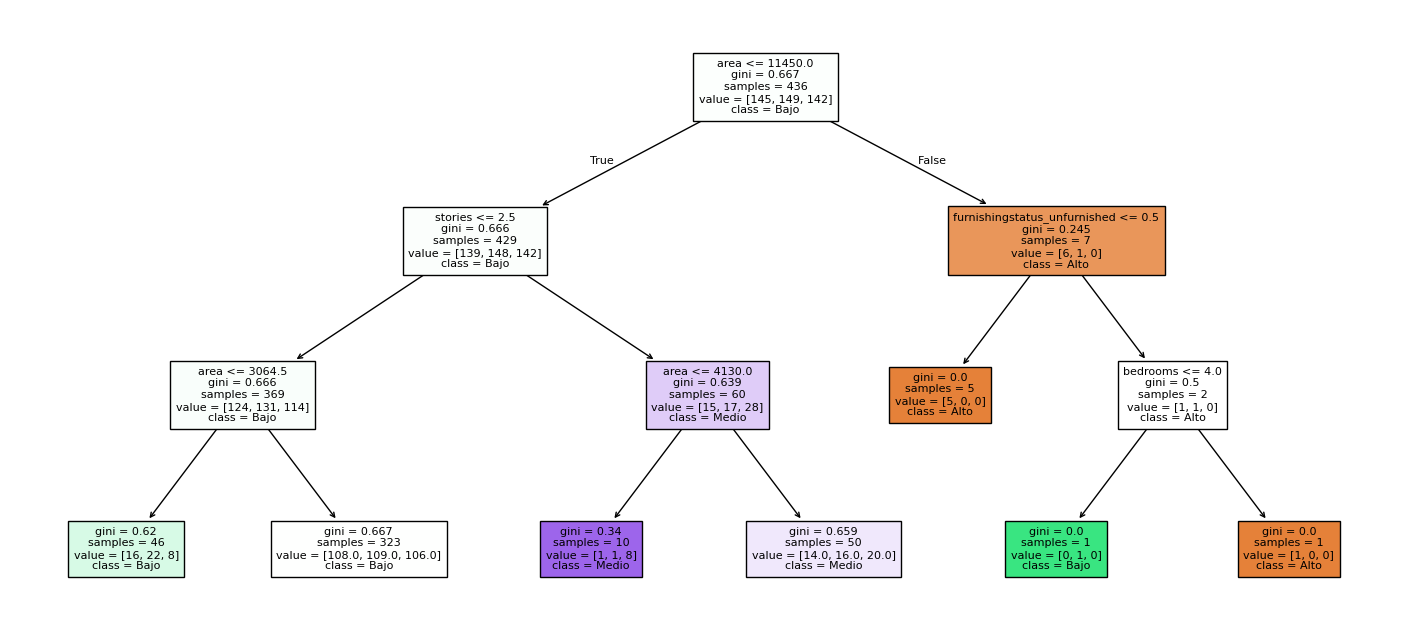

               Modelo           MAE          RMSE        R²
0  Árbol de regresión  1.258021e+06  1.689677e+06  0.435163
1       Random Forest  1.079255e+06  1.452073e+06  0.582850
                        Variable  Importancia
0                           area     0.499487
2                      bathrooms     0.182942
9            airconditioning_yes     0.069544
3                        stories     0.046962
4                        parking     0.041213
1                       bedrooms     0.037886
12  furnishingstatus_unfurnished     0.033664
7                   basement_yes     0.025787
10                  prefarea_yes     0.023572
8            hotwaterheating_yes     0.014294


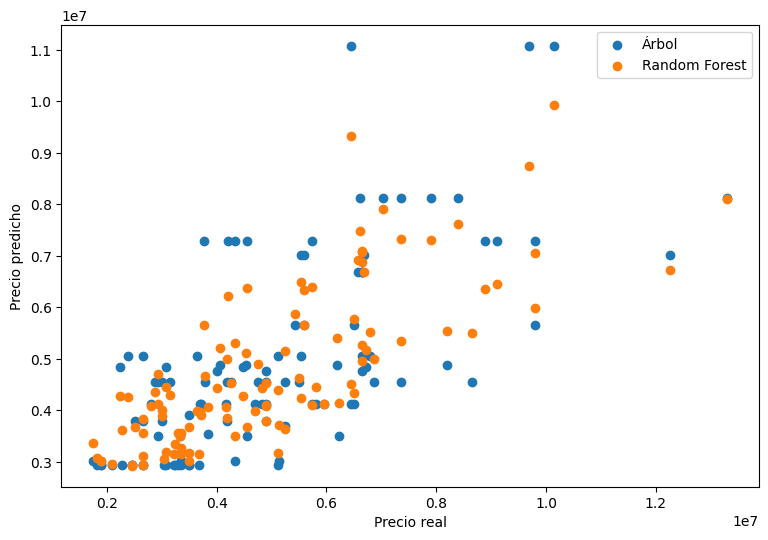

In [1]:
from google.colab import files  # Importo files porque necesito cargar mi archivo Housing.csv directamente desde Google Colab.
import pandas as pd  # Importo pandas porque lo utilizo para leer, organizar y transformar los datos del dataset.
import numpy as np  # Importo numpy porque lo necesito para calcular la raíz cuadrada del error cuadrático.
import matplotlib.pyplot as plt  # Importo matplotlib porque lo utilizo para crear las visualizaciones de los modelos.
from sklearn.model_selection import train_test_split  # Importo esta herramienta porque necesito separar los datos para entrenar y evaluar.
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree  # Importo los árboles porque compararé clasificación y regresión.
from sklearn.ensemble import RandomForestRegressor  # Importo Random Forest porque quiero combinar múltiples árboles de regresión.
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score  # Importo las métricas porque necesito evaluar los modelos.
uploaded = files.upload()  # Permito seleccionar desde mi computador el archivo Housing.csv que utilizaré en el ejercicio.
df = pd.read_csv(next(iter(uploaded)))  # Leo automáticamente el archivo cargado y lo convierto en un DataFrame para trabajar con él.
print(df.head())  # Muestro las primeras filas porque quiero comprobar cómo están organizados inicialmente los datos.
print("Numéricas:", df.select_dtypes(include="number").columns.tolist())  # Identifico automáticamente las columnas numéricas disponibles en el dataset.
print("Categóricas:", df.select_dtypes(exclude="number").columns.tolist())  # Identifico automáticamente las columnas categóricas que necesitan transformación.
y = df["price"]  # Selecciono price como objetivo porque representa el valor numérico que quiero predecir.
X = df.drop(columns="price")  # Elimino price de las entradas porque no debo utilizar la respuesta como variable predictora.
X = pd.get_dummies(X, drop_first=True)  # Transformo las categorías en números porque los modelos necesitan entradas numéricas.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)  # Separo 80% para entrenar y 20% para evaluar manteniendo reproducibilidad.
categorias = pd.qcut(y, 3, labels=["Bajo", "Medio", "Alto"])  # Divido los precios en tres grupos porque quiero convertir temporalmente la regresión en clasificación.
yc_train, yc_test = train_test_split(categorias, test_size=.2, random_state=42, stratify=categorias)  # Separo las categorías conservando una proporción equilibrada entre Bajo, Medio y Alto.
clf = DecisionTreeClassifier(max_depth=3, random_state=42)  # Creo un árbol de decisión pequeño porque quiero clasificar y visualizarlo fácilmente.
clf.fit(X_train, yc_train)  # Entreno el árbol de clasificación porque necesito que aprenda a diferenciar los tres rangos de precio.
print("Accuracy:", accuracy_score(yc_test, clf.predict(X_test)))  # Calculo el accuracy porque quiero conocer qué porcentaje clasificó correctamente.
plt.figure(figsize=(18,8)); plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True, fontsize=8); plt.show()  # Visualizo el árbol para observar las preguntas y decisiones que realiza.
reg = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)  # Creo el árbol de regresión controlando su profundidad y el mínimo de datos para dividir.
reg.fit(X_train, y_train)  # Entreno el árbol de regresión porque quiero obtener predicciones numéricas del precio.
pred_reg = reg.predict(X_test)  # Predigo los precios del conjunto de prueba porque necesito comparar sus valores con los precios reales.
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)  # Creo Random Forest con 100 árboles y profundidad limitada para obtener predicciones más estables.
rf.fit(X_train, y_train); pred_rf = rf.predict(X_test)  # Entreno Random Forest y genero sus predicciones porque necesito evaluar su rendimiento.
resultados = pd.DataFrame({"Modelo":["Árbol de regresión","Random Forest"],"MAE":[mean_absolute_error(y_test,pred_reg),mean_absolute_error(y_test,pred_rf)],"RMSE":[np.sqrt(mean_squared_error(y_test,pred_reg)),np.sqrt(mean_squared_error(y_test,pred_rf))],"R²":[r2_score(y_test,pred_reg),r2_score(y_test,pred_rf)]})  # Construyo la tabla comparativa usando únicamente resultados calculados sobre los datos de prueba.
print(resultados); print(pd.DataFrame({"Variable":X.columns,"Importancia":rf.feature_importances_}).sort_values("Importancia",ascending=False).head(10))  # Muestro las métricas y las variables más importantes para interpretar ambos resultados.
plt.figure(figsize=(9,6)); plt.scatter(y_test,pred_reg,label="Árbol"); plt.scatter(y_test,pred_rf,label="Random Forest"); plt.xlabel("Precio real"); plt.ylabel("Precio predicho"); plt.legend(); plt.show()  # Comparo visualmente los precios reales y predichos para observar el comportamiento de ambos modelos.